This notebook contains the scripts required to reproduce the results in Leung and van den Heever (202X): "Deforestation Impacts on Clouds and Precipitation Over Borneo Vary Across the Diurnal Cycle".

Contact: Gabrielle Leung (gabrielle.leung@colostate.edu)
Last edited: 5 June 2025

I have tried to make this notebook as lightweight as possible to facilitate future revisions, with most (if not all) the intermediate processing steps performed on the model output being run in the other scripts within this repo. I will indicate the relevant scripts for each figure.

# Imports and Paths

In [24]:
# libraries shared across most of these plots
import glob
import os
import itertools
import numpy as np
import pandas as pd
import xarray as xr
import datetime as dt
import dask.distributed as dd
from scipy.stats import gaussian_kde
import metpy.calc as mpcalc
import metpy.units as units

# model constants defined in 'shared_model_params.py'
from shared_model_params import (
    nx,
    ny,
    dx,
    dy,
    bxy,
    alt,
    p00,
    rd,
    cp,
    dz,
    compute_cond,
    compute_intcond,
    get_rams_landcover,
)

In [25]:
client = dd.Client("solvarg:1111")
client

# To see the daskboard, on my terminal the command is:  ssh -L 9999:snowfall1:8787 snowfall1
# then you can go to localhost:9999/status

<Client: 'tcp://10.1.20.22:1111' processes=12 threads=12, memory=600.00 GiB>

## Plotting parameters

In [26]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.gridspec as gs

brown = "#6b5a34"
green = "#8cab78"

from shared_plotting import *

char = "abcdefghijklmnopqrstuvwxyz"

## Define paths

In [27]:
runs = ["lc1960", "lc2019"]
run_names = ["VEG1960", "VEG2019"]

modeldataPath = "/squall/gleung/borneolcc/"  # raw model output
anaPath = "/squall/gleung/borneolcc-analysis/"  # intermediate processed files
tobacPath = f"{anaPath}/tobac/"  # tobac output
ahiPath = "/squall/gleung/ahi/"
figPath = "/squall/gleung/borneolcc-figures/paper-figs/"  # final figures

## Read in RAMS coordinates

In [28]:
from shared_model_params import get_rams_output, rams_dims_anal

# read in the topography
topo = get_rams_output(
    f"{modeldataPath}/lc1960/rte/a-A-2019-09-16-140000-g1.h5",
    variables=["GLON", "GLAT", "TOPT"],
    dims=rams_dims_anal,
)[["GLON", "GLAT", "TOPT"]].compute()

# Figure 1: Simulation vs. satellite quicklook

This uses:
* AHI full disk data downloaded using the script 'download_himawari_data.py'
* RAMS raw output for the specified times
* tobac feature lists (final_cells_land_nofog.pq) and cloud masks (cond_masks_column_anvil/) created using the series of tobac scripts

In [29]:
import himawari_api as hapi
from satpy import Scene


def plot_truecolor(
    time: dt.datetime,
    ax: plt.Axes,
    bbox: tuple[float, float, float, float] = (108.77, -0.1, 111.53, 2.78),
) -> plt.Axes:
    """This function plots the Himawari true color imagery.

    Arguments:
        time (dt.datetime): time to pull AHI imagery for
        ax (plt.Axes): axis to plot imagery on
        bbox (tuple[float,float,float,float]): bounding box as (lonmin, latmin, lonmax, latmax)

    Returns:
        plt.Axes: output axis
    """

    # read correct scene and bands
    scn = Scene(filenames=satpaths_dict.get(time), reader="ahi_hsd")
    scn.load(["B01", "B02", "B03", "B04"])
    scn = scn.resample(resampler="native")

    # crop to bounding box given
    scn = scn.crop(ll_bbox=bbox)
    scn = scn.resample(resampler="native")

    # load data
    scn.load(["true_color"])
    crs = scn["true_color"].attrs["area"].to_cartopy_crs()

    # plot!
    tc = scn.show("true_color")

    ax.imshow(
        tc.pil_image(),
        transform=crs,
        extent=crs.bounds,
        origin="upper",
        rasterized=True,
    )

    return ax

In [30]:
# reading in the cloud objects identified with tobac
run = "lc2019"
tobac_fts = pd.read_parquet(f"{tobacPath}/{run}_rte/final_cells_land_nofog.pq")

In [31]:
# group satellite data files into timesteps
satpaths_dict = hapi.group_files(
    glob.glob(f"{ahiPath}HIMAWARI-8/AHI-L1b-FLDK/*/*/*/*/*"),
    key="start_time",
)

# need to run this once to get the correct CRS
scn = Scene(
    filenames=satpaths_dict.get(pd.to_datetime("2019-09-16 20:00")),
    reader="ahi_hsd",
)
scn.load(["B01", "B02", "B03", "B04"])
scn = scn.resample(resampler="native")
scn = scn.crop(ll_bbox=(108.65, -0.164, 111.61, 2.85))
scn = scn.resample(resampler="native")

scn.load(["true_color"])
crs = scn["true_color"].attrs["area"].to_cartopy_crs()

In [ ]:
fig = plt.figure(figsize=(14, 10))
spec = gs.GridSpec(ncols=3, nrows=2, figure=fig)

# set up two rows of subplots
am_axes = [fig.add_subplot(spec[0, i], projection=crs) for i in range(2)] + [
    fig.add_subplot(spec[0, 2])
]
pm_axes = [fig.add_subplot(spec[1, i], projection=crs) for i in range(2)] + [
    fig.add_subplot(spec[1, 2])
]

times = ["2019-09-17-030000", "2019-09-17-080000"]

i = 0

for axes, time in zip([am_axes, pm_axes], times):
    # plot Himawari imagery on leftmost panels
    axes[0] = plot_truecolor(pd.to_datetime(time), axes[0])

    # middle panel have integrated condensate
    # right panels have integrated condensate and tobac features/tracks

    # read in RAMS data
    ds = get_rams_output(
        f"{modeldataPath}/{run}/rte/a-L-{time}-g1.h5",
        variables=["PI", "THETA", "RV", "RCP", "RSP", "RPP"],
    )

    # compute integrated condensate for plotting
    ds = compute_cond(ds, return_dens=True)
    ds = compute_intcond(ds, use_dens=True)

    # add lat/lons for plotting
    ds = xr.merge([ds, topo.GLON, topo.GLAT])

    # remove sponge points
    ds = ds.assign_coords(
        {"xdist": ds.x * dx / 1000, "ydist": ds.y * dy / 1000}
    )
    ds = ds.sel(x=slice(bxy, nx - bxy), y=slice(bxy, ny - bxy)).compute()
    ds["x"] = ds.x + bxy
    ds["y"] = ds.y + bxy

    # plot integrated condensate (full domain)
    axes[1].pcolormesh(
        ds.GLON,
        ds.GLAT,
        ds.intCON,
        cmap=cloud,
        norm=mcolors.LogNorm(vmin=1e-3, vmax=1e2),
        transform=ccrs.PlateCarree(),
        rasterized=True,
    )

    # subset the zoomed in plot
    plot = ds.sel(x=slice(1200, 1700), y=slice(700, 1200))
    cplot = axes[2].pcolormesh(
        plot.xdist,
        plot.ydist,
        plot.intCON,
        cmap=cloud,
        norm=mcolors.LogNorm(vmin=1e-3, vmax=1e2),
        rasterized=True,
    )

    # subsetting the tobac features
    ft_plot = tobac_fts[tobac_fts.time == pd.to_datetime(time)]
    ft_plot = ft_plot[
        (ft_plot.x >= 1200)
        & (ft_plot.x <= 1700)
        & (ft_plot.y >= 700)
        & (ft_plot.y <= 1200)
    ]

    # read the corresponding cloud mask file
    cldmask_plot = xr.open_dataset(
        f"{tobacPath}/{run}_rte/cond_masks_column_anvil/a-L-{time}.h5"
    ).sel(x=slice(bxy, nx - bxy - 1), y=slice(bxy, ny - bxy - 1))

    # for each unique feature at this timestep, find corresponding cloud mask and plot as outline
    for f in ft_plot.feature.unique():
        outline = (
            cldmask_plot.where(cldmask_plot.segmentation_mask == f).sum(dim="z")
            >= 1
        )

        axes[2].contour(
            outline.x * dx / 1000,
            outline.y * dy / 1000,
            outline.segmentation_mask,
            colors="gray",
            linewidths=1.5,
        )

    # for each cell, plot full cell track to show motion
    for c in ft_plot.cell.unique():
        axes[2].plot(
            tobac_fts[tobac_fts.cell == c].x * dx / 1000,
            tobac_fts[tobac_fts.cell == c].y * dy / 1000,
            linewidth=1,
            color=red,
        )

    # plot current position of cloud with dot
    axes[2].scatter(
        ft_plot.x * dx / 1000,
        ft_plot.y * dy / 1000,
        marker="o",
        s=5,
        linewidth=1,
        facecolor="None",
        edgecolor=red,
        zorder=10,
    )

    # cleaning up plot with coastlines, topography, etc.
    for ax, lcol in zip(axes[:2], ["black", "white"]):
        ax.coastlines(color=lcol)
        add_latlon(ax)
        add_topography(ax, topo, lcol=lcol)

        # draw the bounding box for the third panel (zoomed in)
        ax.plot(
            [110.32, 110.99, 110.99, 110.32, 110.32],
            [0.78, 0.78, 1.46, 1.46, 0.78],
            transform=ccrs.PlateCarree(),
            color=red,
        )

    # axes limits
    for ax in axes[:2]:
        ax.set_xlim(ds.GLON.min(), ds.GLON.max())
        ax.set_ylim(ds.GLAT.min(), ds.GLAT.max())
    axes[2].set_ylim(105, 180)
    axes[2].set_xlim(180, 255)

    # label axes
    axes[2].set_ylabel("Zonal Distance (km)")
    axes[2].set_xlabel("Meridional Distance (km)")

    for ax, lcol in zip(axes, ["black", "white", "white"]):
        ax.set_title(f" ({char[i]})", y=0.9, color=lcol)
        i += 1


# label what fields are plotted per column
for ax, label in zip(
    am_axes, ["AHI True Color", "Simulated Clouds", "Cloud Mask"]
):
    ax.text(
        0.5,
        1.0,
        label,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=25,
    )

# label the times plotted per row
for axes, time in zip([am_axes, pm_axes], times):
    axes[0].text(
        -0.2,
        0.5,
        f"{(pd.to_datetime(time)+dt.timedelta(hours=8)).strftime('%I:%M %p')}",
        transform=axes[0].transAxes,
        rotation=90,
        ha="right",
        va="center",
        fontsize=25,
    )

# colorbar axis
cax = fig.add_axes(
    [
        am_axes[2].get_position().x1 + 0.1,
        pm_axes[0].get_position().y0,
        0.05,
        am_axes[0].get_position().y1 - pm_axes[0].get_position().y0,
    ]
)
plt.colorbar(cplot, cax=cax, label="Integrated Condensate (mm)")

plt.tight_layout()

plt.savefig(f"{figPath}/fig1-quicklook.pdf", dpi=500)
plt.close("all")

/home/gleung/miniforge3/envs/borneolcc/lib/python3.12/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 1.58 GiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/tmp/ipykernel_651096/335583616.py:87: UserWarning: The following kwargs were not used by contour: 'rasterized'
  axes[2].contour(
/tmp/ipykernel_651096/335583616.py:87: UserWarning: The following kwargs were not used by contour: 'rasterized'
  axes[2].contour(
/tmp/ipykernel_651096/335583616.py:87: UserWarning: The following kwargs were not used by contour: 'rasterized'
  axes[2].contour(
/tmp/ipykernel_651096/335583616.py:87: UserWarning: The following kwargs were not used by contour: 'rasterized'
  axes[2].contour(
/tmp/ipykernel_651096/335583616.py:87: UserWarning: The following kwargs were not used by contour: 'rasterized'
  axes[2].contour(
/tmp/ipykernel_651096/335583616.py:87: UserWarning: The following kwargs were not used by con

# Figure 2: land cover past vs. present

This only uses the RAMS surface files for the two runs. 

## Define colormap

In [47]:
from matplotlib.patches import Patch

landuse = {
    "vals": np.arange(0.5, 21.5, 1),
    "labels": [
        "Ocean",
        "Lakes, rivers, streams",
        "Ice",
        "Desert/bare soil",
        "Evergreen needleleaf",
        "Deciduous needleleaf",
        "Deciduous broadleaf",
        "Evergreen broadleaf",
        "Short grass",
        "Tall grass",
        "Semi-desert",
        "Tundra",
        "Evergreen shrub",
        "Deciduous shrub",
        "Mixed woodland",
        "Crop/mixed farming",
        "Irrigated crop",
        "Bog/marsh",
        "Wooded grassland",
        "Urban and built-up",
        "Wetland evergreen broadleaf",
    ],
    "cmap": [
        (r / 255, g / 255, b / 255)
        for (r, g, b) in [
            (53, 93, 121),
            (200, 222, 249),
            (252, 252, 251),
            (244, 237, 210),
            (130, 174, 147),
            (136, 177, 153),
            (162, 194, 180),
            (146, 167, 132),
            (253, 245, 187),
            (246, 244, 174),
            (216, 195, 156),
            (185, 204, 224),
            (227, 212, 184),
            (206, 220, 170),
            (186, 197, 157),
            (237, 198, 130),
            (143, 184, 159),
            (57, 55, 84),
            (104, 94, 71),
            (180, 80, 69),
            (170, 130, 74),
        ]
    ],
}

landuse_cmap = mcolors.LinearSegmentedColormap.from_list(
    "landuse", landuse.get("cmap")
)

leg_elements = [
    Patch(facecolor=col, edgecolor="black", label=lab)
    for col, lab in zip(landuse.get("cmap"), landuse.get("labels"))
]

## Read RAMS surface files

In [48]:
past = get_rams_landcover(
    f"{modeldataPath}/{runs[0]}/rte/a-A-2019-09-16-140000-g1.h5"
).sel(x=slice(bxy, nx - bxy), y=slice(bxy, ny - bxy))
pres = get_rams_landcover(
    f"{modeldataPath}/{runs[1]}/rte/a-A-2019-09-16-140000-g1.h5"
).sel(x=slice(bxy, nx - bxy), y=slice(bxy, ny - bxy))

## Make plot

/tmp/ipykernel_651096/449993032.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


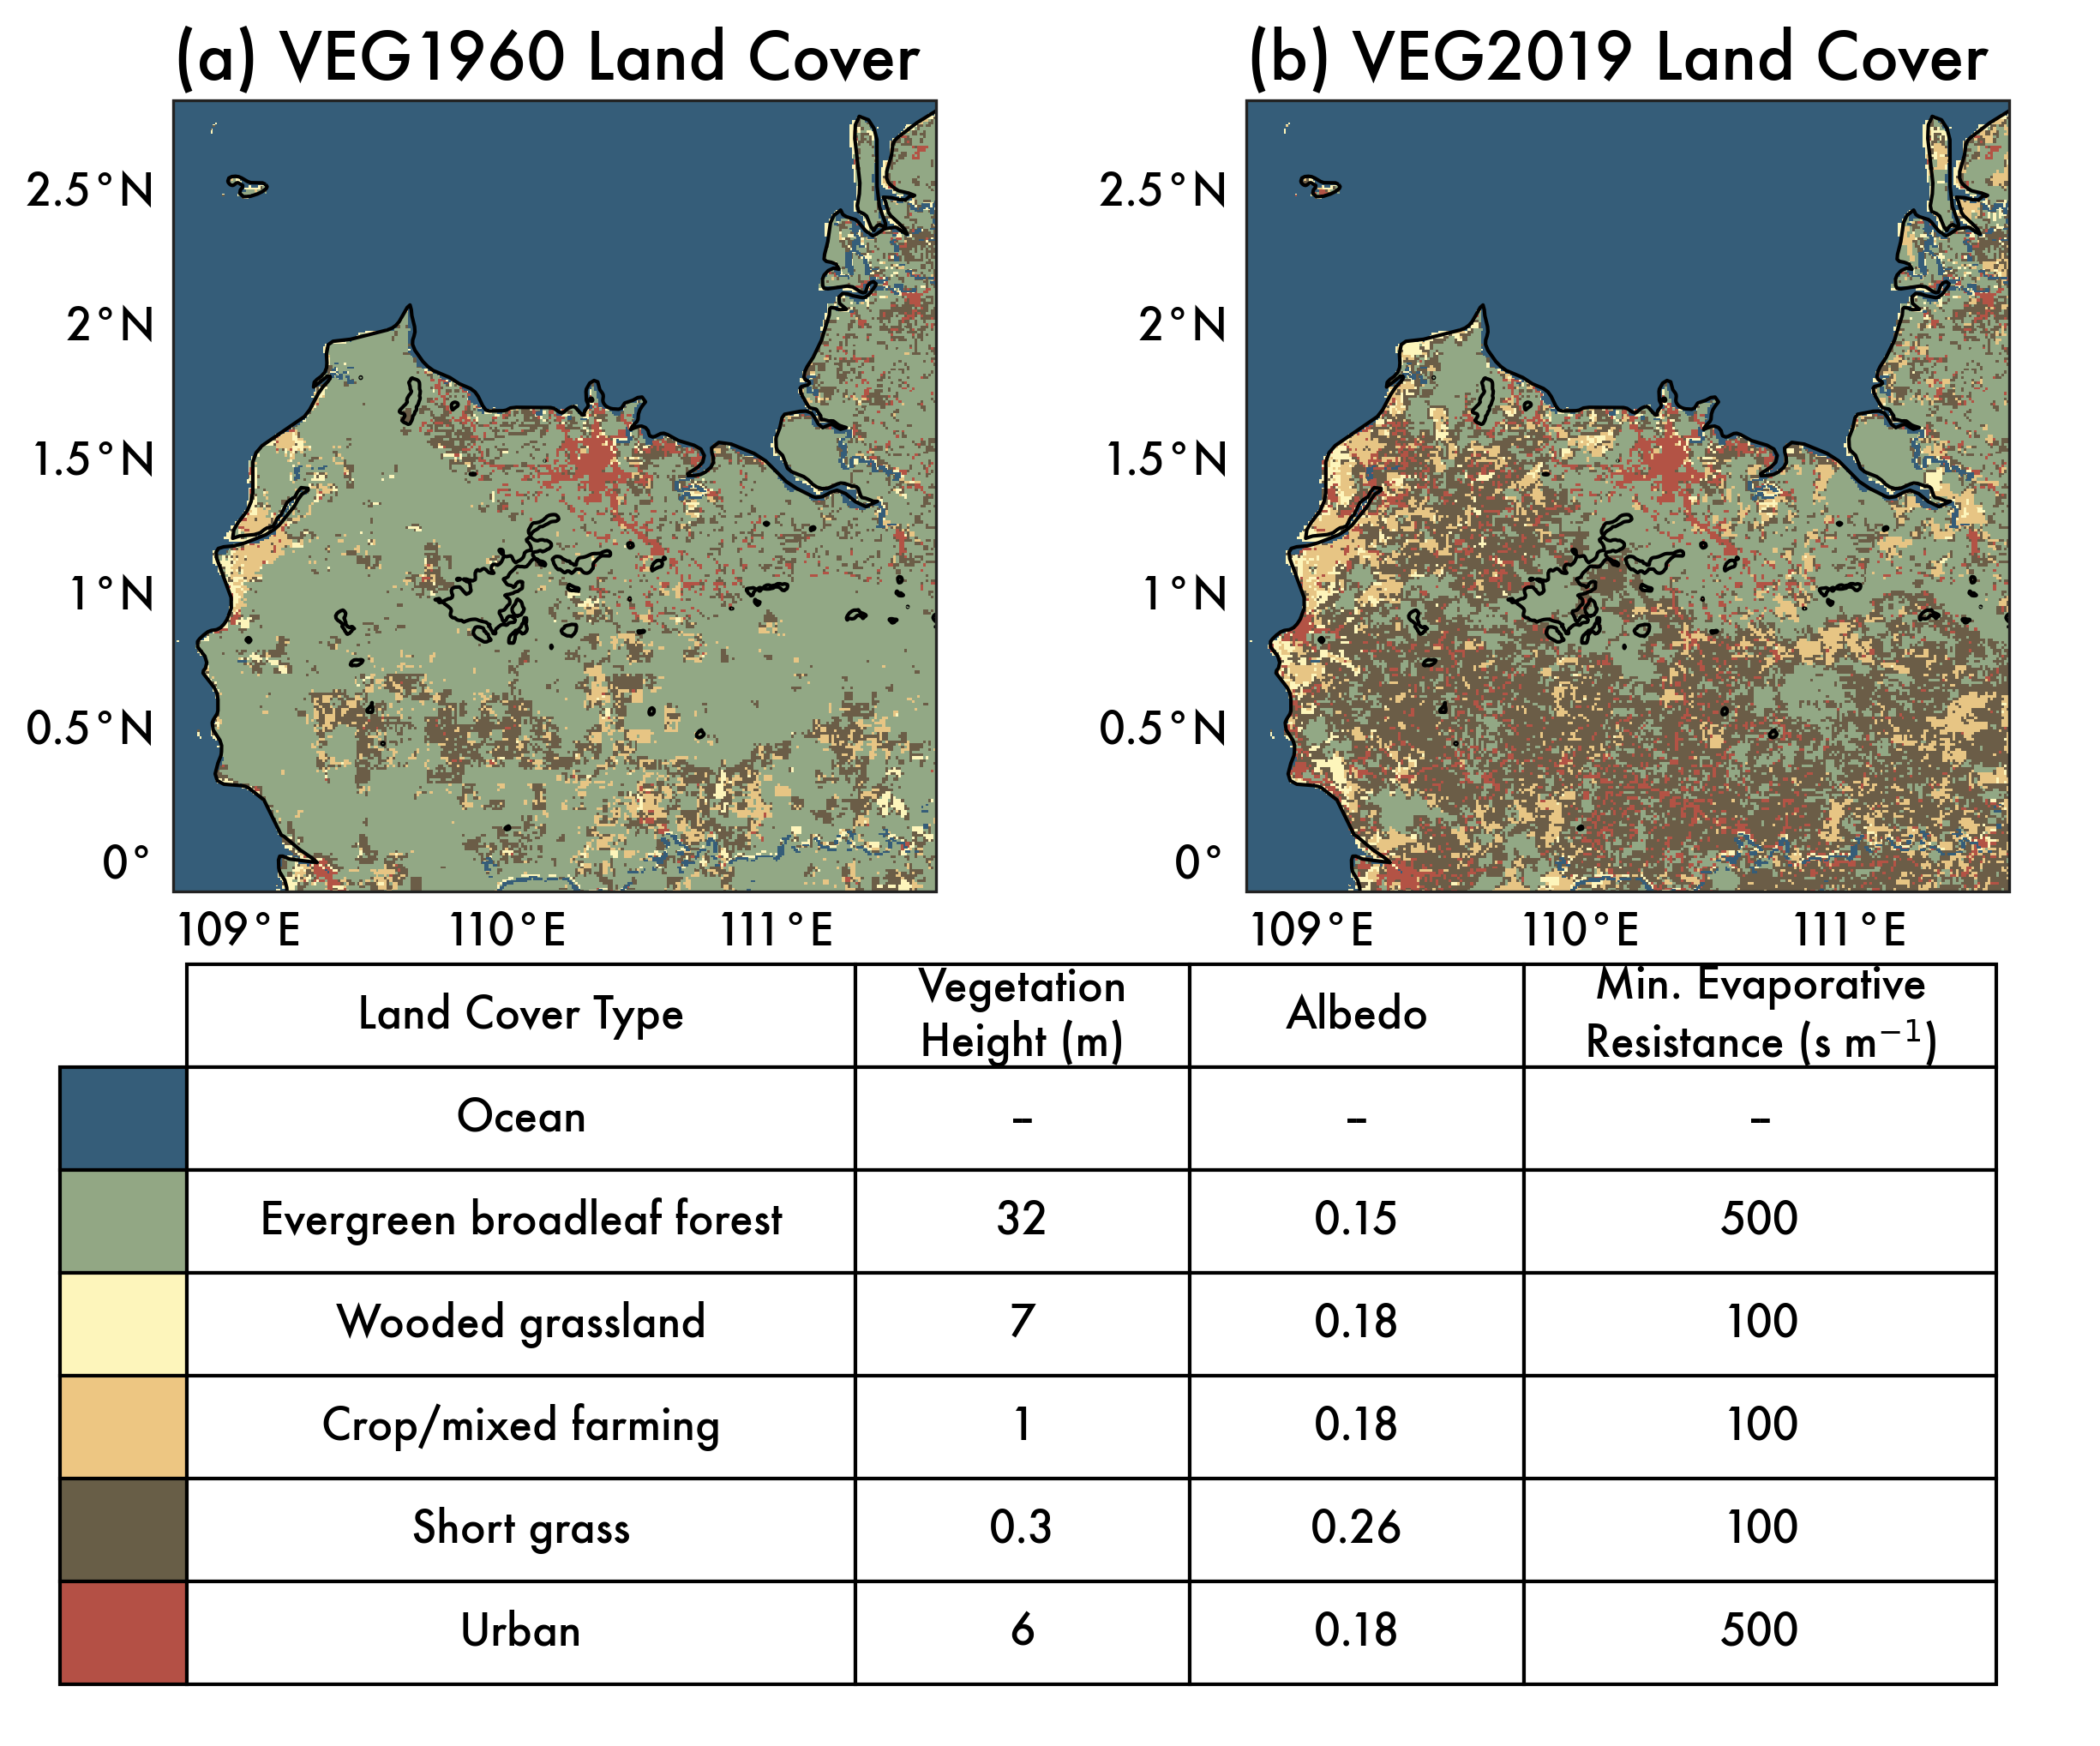

In [49]:
# set up figure
fig = plt.figure(figsize=(8.5, 7))
spec = gs.GridSpec(ncols=2, nrows=4, figure=fig)
spec.update(hspace=0.1)
axes = [
    fig.add_subplot(spec[:2, i], projection=ccrs.PlateCarree())
    for i in range(2)
]
lax = fig.add_subplot(spec[2:, :])

# plot land cover for each run
for i, (ax, plot, name) in enumerate(zip(axes, [past, pres], run_names)):
    ax.pcolormesh(
        plot.GLON,
        plot.GLAT,
        plot.lc,
        cmap=landuse_cmap,
        vmin=0,
        vmax=20,
        rasterized=True,
    )
    ax.set_title(f"({char[i]}) {name} Land Cover")

    ax.coastlines()
    add_latlon(ax)
    add_topography(ax, topo, lcol="black")

    ax.set_xlim(plot.GLON.min(), plot.GLON.max())
    ax.set_ylim(plot.GLAT.min(), plot.GLAT.max())

# Table showing the important vegetation parameters
# manually took these from RAMS source code
tab = lax.table(
    cellText=[
        ["Ocean", "--", "--", "--"],
        ["Evergreen broadleaf forest", 32, 0.15, 500],
        ["Wooded grassland", 7, 0.18, 100],
        ["Crop/mixed farming", 1, 0.18, 100],
        ["Short grass", 0.3, 0.26, 100],
        ["Urban", 6, 0.18, 500],
    ],
    colLabels=[
        "Land Cover Type",
        "Vegetation\nHeight (m)",
        "Albedo",
        "Min. Evaporative\nResistance (s m$^{-1}$)",
    ],
    rowLabels=["        "] * 6,
    rowColours=[
        l
        for i, l in enumerate(landuse.get("cmap"))
        if i in [0, 7, 8, 15, 18, 19]
    ],
    colWidths=[0.34, 0.17, 0.17, 0.24],
    fontsize=280,
    loc="center",
    cellLoc="center",
)

tab.scale(1, 2.4)
lax.axis("off")

plt.tight_layout()
plt.savefig(f"{figPath}/fig2_landcover_table.pdf", dpi=500)
plt.show()

# Figure 3: Energy budget

This figure uses the mean energy budget over land calculated using the script 'calculate_energybudget.py'.

## Read in processed SEB

In [34]:
# read in processed SEB
past = xr.open_dataset(f"{anaPath}/processed/seb/diurn_land_lc1960.h5")
pres = xr.open_dataset(f"{anaPath}/processed/seb/diurn_land_lc2019.h5")

## Make plot

<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:46: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_651096/717305482.py:46: SyntaxWarning: invalid escape sequence '\D'
  axes[1].set_ylabel("$\Delta$ W m$^{-2}$")


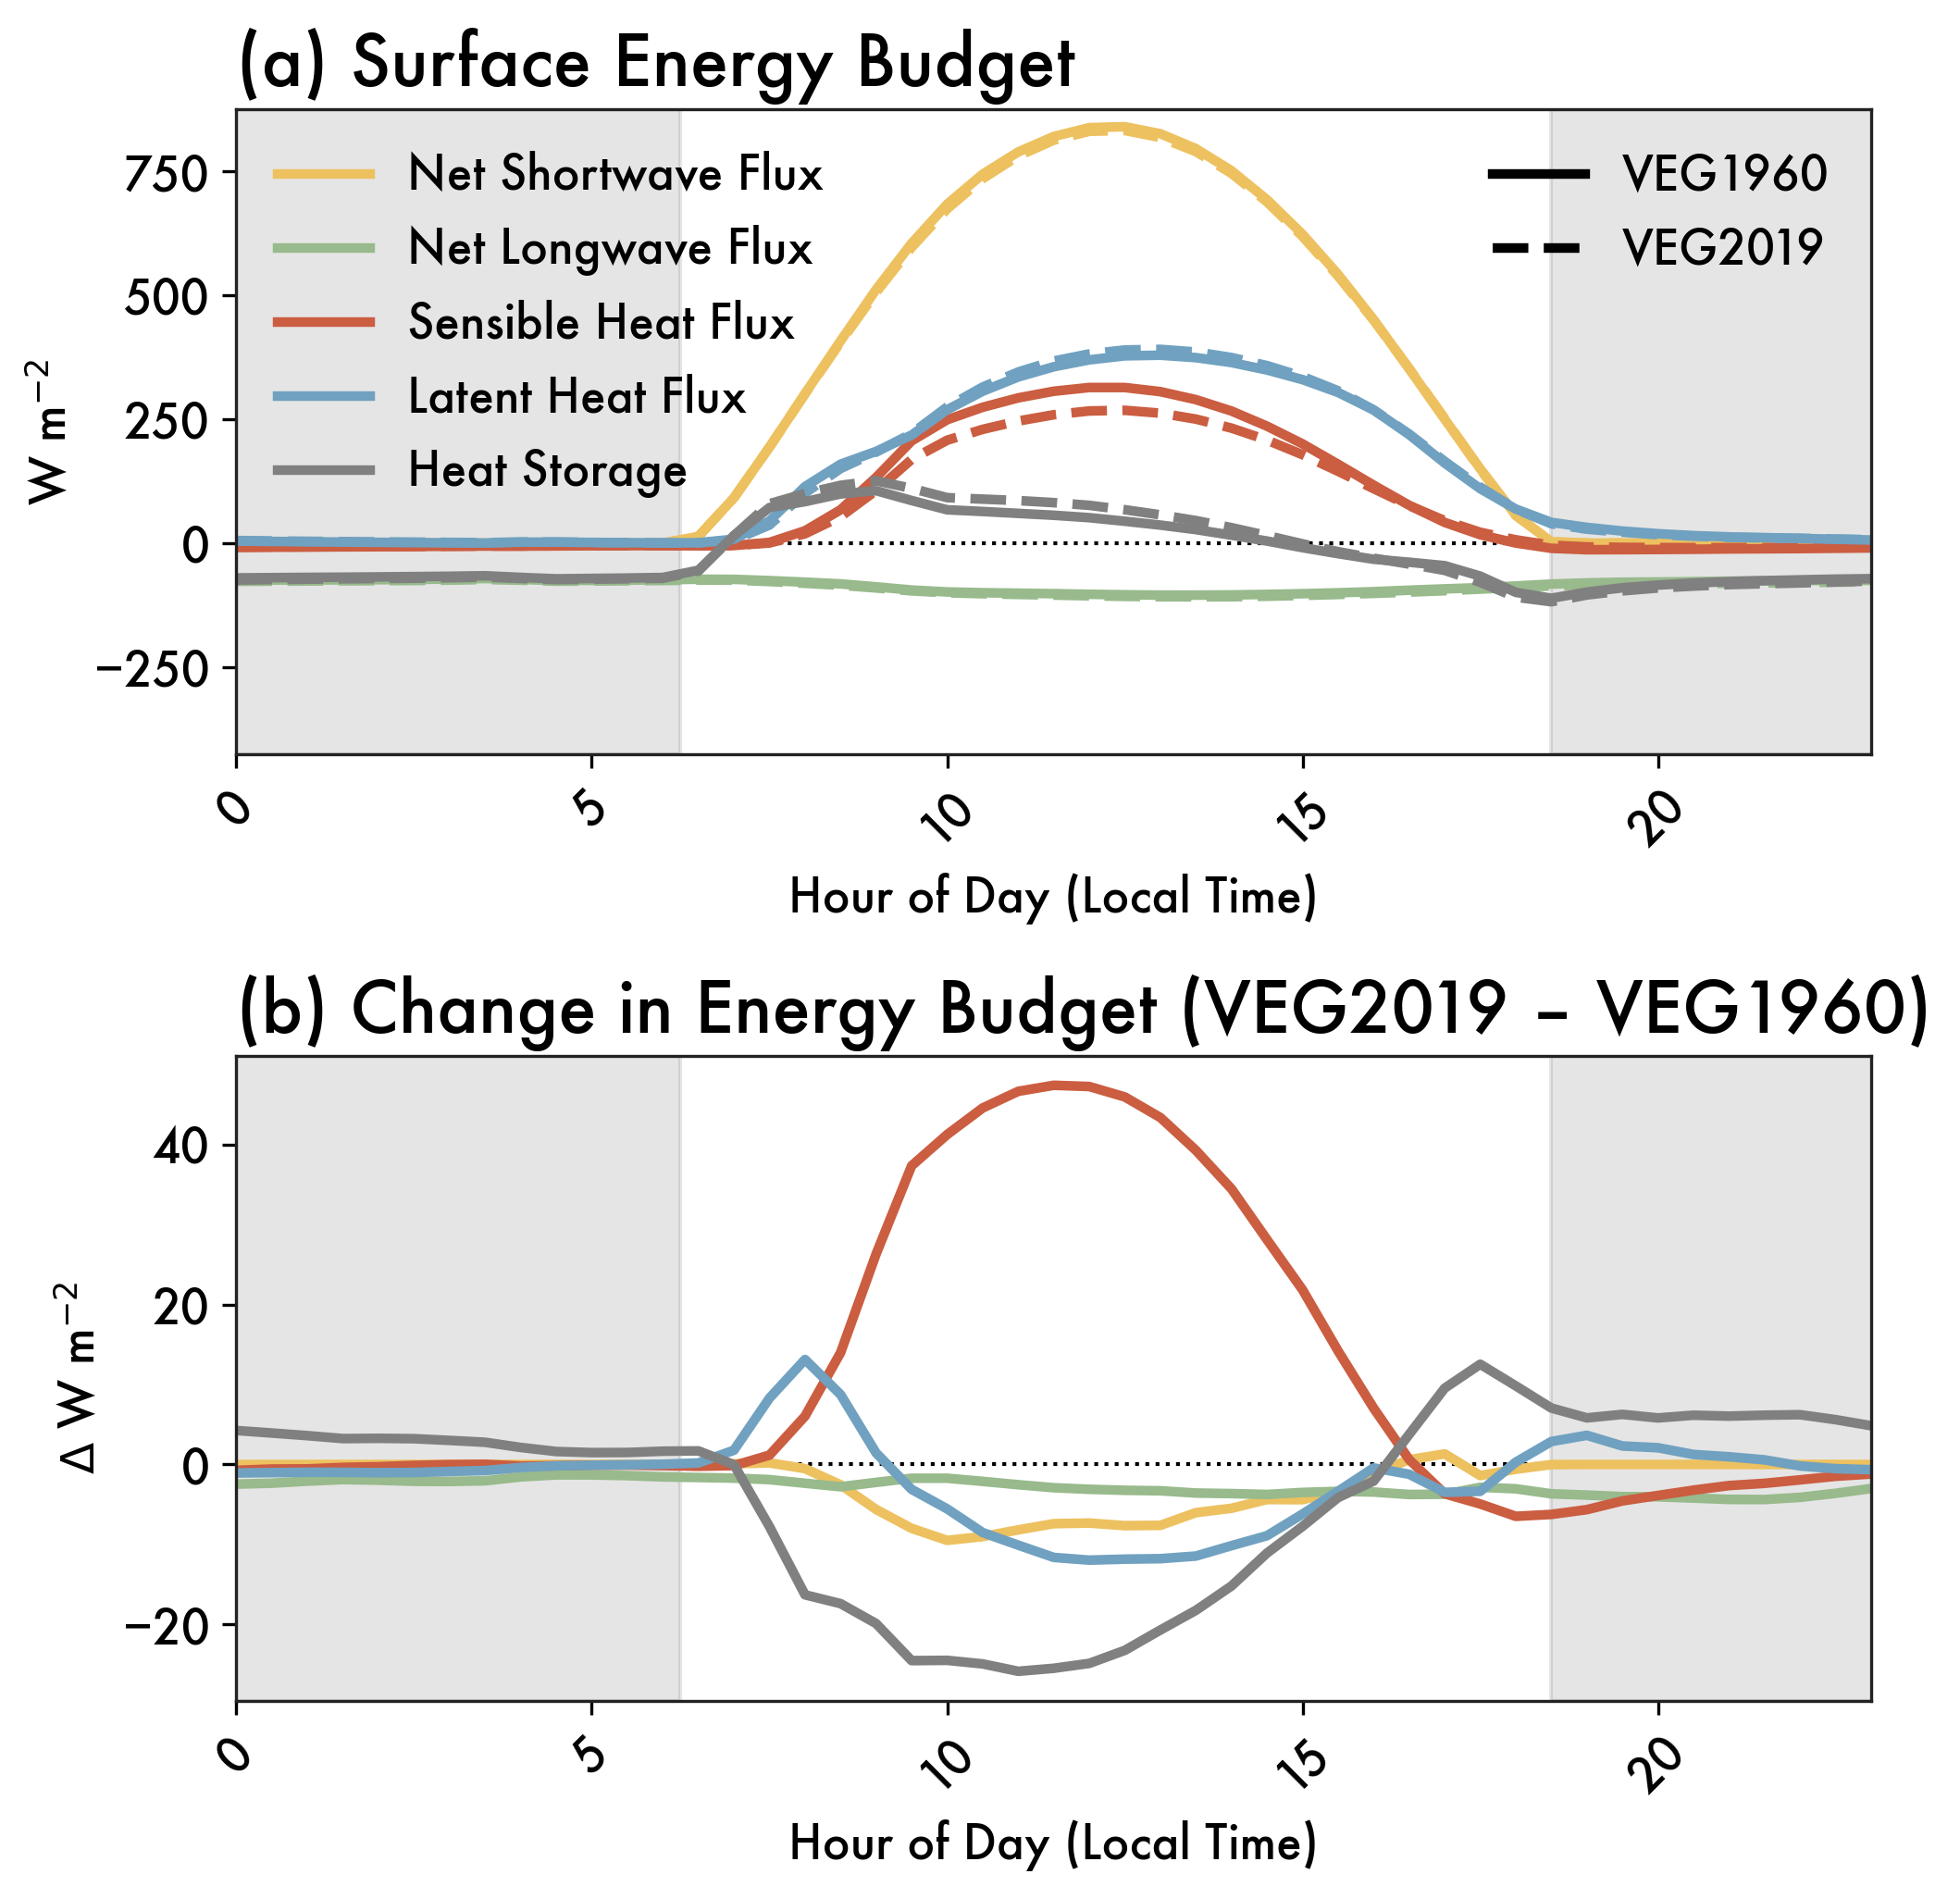

In [45]:
fig, axes = plt.subplots(2, 1, figsize=(7, 7))

# iterate over terms in energy budget
for var, col, lab in zip(
    ["swnet", "lwnet", "shf", "lhf", "g"],
    ["#edc15f", "#98ba8c", "#CB5D41", "#70A1C0", "gray"],
    [
        "Net Shortwave Flux",
        "Net Longwave Flux",
        "Sensible Heat Flux",
        "Latent Heat Flux",
        "Heat Storage",
    ],
):
    # iterate over simulations
    for run, ls in zip([past, pres], ["-", "--"]):
        # these terms are negative in SEB (i.e., terms which transfer heat FROM surface TO atmosphere/canopy)
        if var in ["shf", "lhf", "g"]:
            plot = -run[var]
        else:
            plot = run[var]

        # so labels aren't doubled
        if ls == "--":
            lab = None

        # actual plot
        axes[0].plot(
            run.time,
            plot,
            color=col,
            ls=ls,
            label=lab,
        )

    # plot differences
    axes[1].plot(run.time, pres[var] - past[var], color=col)

# labels for clarity
for ax in axes:
    add_diurnal_annotation(ax)

axes[0].set_ylim(-425, 875)

axes[0].set_ylabel("W m$^{-2}$")
axes[1].set_ylabel("$\Delta$ W m$^{-2}$")

axes[0].set_title("(a) Surface Energy Budget")
axes[1].set_title("(b) Change in Energy Budget (VEG2019 – VEG1960)")

l = axes[0].legend(loc="upper left")
axes[0].add_artist(l)
axes[0].legend(
    handles=[
        mlines.Line2D([], [], color="black", ls="-"),
        mlines.Line2D([], [], color="black", ls="--"),
    ],
    labels=["VEG1960", "VEG2019"],
    loc="upper right",
    handlelength=2,
)

for ax in axes:
    ax.set_xlim(0, 23)

plt.savefig(f"{figPath}/fig3_seb.pdf")
plt.show()
plt.close("all")